#  **Import Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

#   **Data Loading & Understanding**

In [2]:
ipl = pd.read_csv("ipl_matches.csv")

In [3]:
ipl.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
ipl.shape

(756, 18)

In [5]:
ipl.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [6]:
ipl.dtypes.to_frame(name = 'Data Type')

,Data Type
id,int64
Season,object
city,object
date,object
team1,object
team2,object
toss_winner,object
toss_decision,object
result,object
dl_applied,int64


In [7]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   Season           756 non-null    object
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

In [8]:
ipl.describe()

,id,dl_applied,win_by_runs,win_by_wickets
count,756.000000,756.000000,756.000000,756.000000
mean,1792.178571,0.025132,13.283069,3.350529
std,3464.478148,0.156630,23.471144,3.387963
min,1.000000,0.000000,0.000000,0.000000
25%,189.750000,0.000000,0.000000,0.000000
50%,378.500000,0.000000,0.000000,4.000000
75%,567.250000,0.000000,19.000000,6.000000
max,11415.000000,1.000000,146.000000,10.000000


In [9]:
ipl.isnull().sum()

id                   0
Season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [10]:
ipl.duplicated().sum()

np.int64(0)

<br><br>

#    **Data Cleaning**

**Handle Missing Values**

In [11]:
ipl.drop(columns = ['umpire3'], inplace = True, errors = 'ignore')

In [12]:
ipl['city'] = ipl['city'].fillna('Dubai')
ipl['umpire1'] = ipl['umpire1'].ffill().bfill()
ipl['umpire2'] = ipl['umpire2'].ffill().bfill()

In [13]:
ipl.fillna("Unknown", inplace = True)

In [14]:
ipl.isnull().sum().to_frame(name = 'Null Count')

,Null Count
id,0
Season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [15]:
ipl.dtypes.to_frame(name = 'Data Type')

,Data Type
id,int64
Season,object
city,object
date,object
team1,object
team2,object
toss_winner,object
toss_decision,object
result,object
dl_applied,int64


In [16]:
ipl['date'] = pd.to_datetime(ipl['date'], dayfirst = True)

In [17]:
team_name_map = {
    
    'Pune Warriors': 'Rising Pune Supergiants',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Rising Pune Supergiants': 'Rising Pune Supergiants',
    
    'Delhi Daredevils': 'Delhi Capitals',
    'Delhi Capitals': 'Delhi Capitals'
}

In [18]:
team_cols = ['team1', 'team2', 'toss_winner', 'winner']

for col in team_cols:
    ipl[col] = ipl[col].replace(team_name_map)

In [19]:
for col in team_cols:
    print(col, ipl[col].unique())

team1 ['Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Royal Challengers Bangalore'
 'Kolkata Knight Riders' 'Delhi Capitals' 'Kings XI Punjab'
 'Chennai Super Kings' 'Rajasthan Royals' 'Deccan Chargers'
 'Kochi Tuskers Kerala']
team2 ['Royal Challengers Bangalore' 'Rising Pune Supergiants'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Delhi Capitals'
 'Sunrisers Hyderabad' 'Mumbai Indians' 'Gujarat Lions' 'Rajasthan Royals'
 'Chennai Super Kings' 'Deccan Chargers' 'Kochi Tuskers Kerala']
toss_winner ['Royal Challengers Bangalore' 'Rising Pune Supergiants'
 'Kolkata Knight Riders' 'Kings XI Punjab' 'Sunrisers Hyderabad'
 'Mumbai Indians' 'Gujarat Lions' 'Delhi Capitals' 'Chennai Super Kings'
 'Rajasthan Royals' 'Deccan Chargers' 'Kochi Tuskers Kerala']
winner ['Sunrisers Hyderabad' 'Rising Pune Supergiants' 'Kolkata Knight Riders'
 'Kings XI Punjab' 'Royal Challengers Bangalore' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Lions' 'Chennai Super Kings' 'R

In [20]:
ipl.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,IPL-2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,IPL-2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiants,Rising Pune Supergiants,field,normal,0,Rising Pune Supergiants,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,IPL-2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,IPL-2017,Indore,2017-04-08,Rising Pune Supergiants,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,IPL-2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,AK Chaudhary,C Shamshuddin


<br><BR>

#  **Exploratory Data Analysis(EDA)**

In [21]:
num_cols = ipl.select_dtypes(include=['int64','float64']).columns
cat_cols = ipl.select_dtypes(include=['object']).columns

**Winner Distribution**

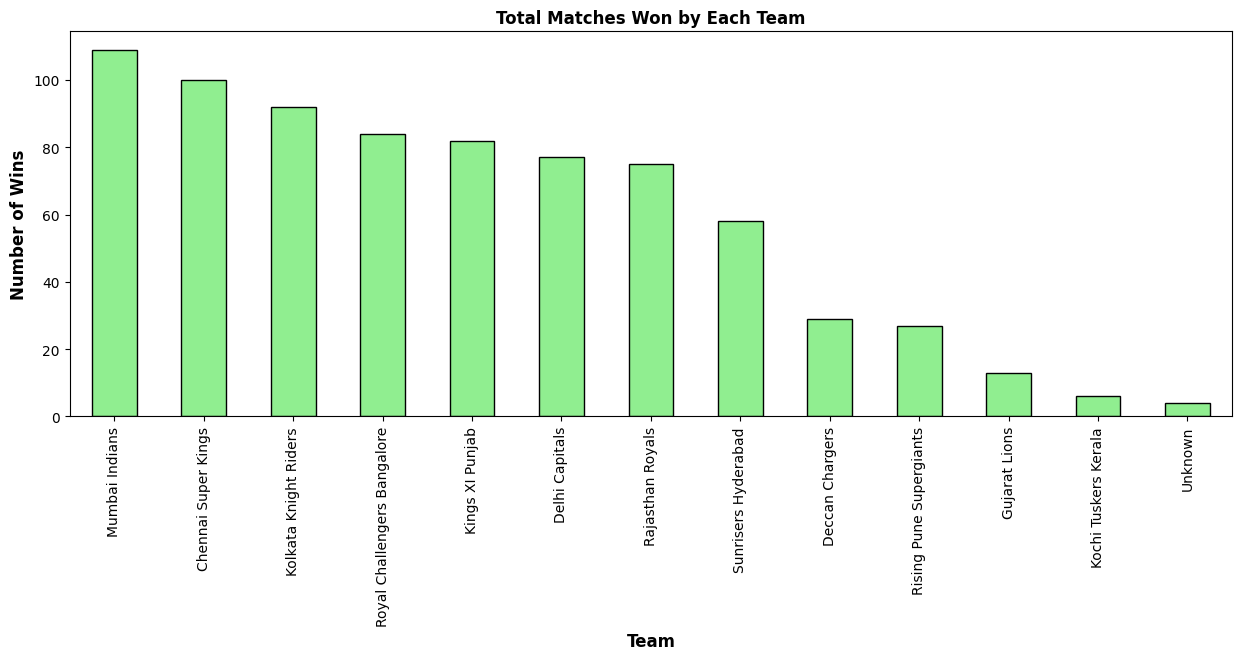

In [22]:
plt.figure(figsize=(15,5))
ipl['winner'].value_counts().plot(kind='bar',color = 'lightgreen',edgecolor = 'black')
plt.title("Total Matches Won by Each Team",fontsize = 12,fontweight = 'bold')
plt.xlabel("Team",fontsize = 12,fontweight = 'bold')
plt.ylabel("Number of Wins",fontsize = 12,fontweight = 'bold')
plt.xticks(rotation=90)
plt.show()

**Toss Analysis**

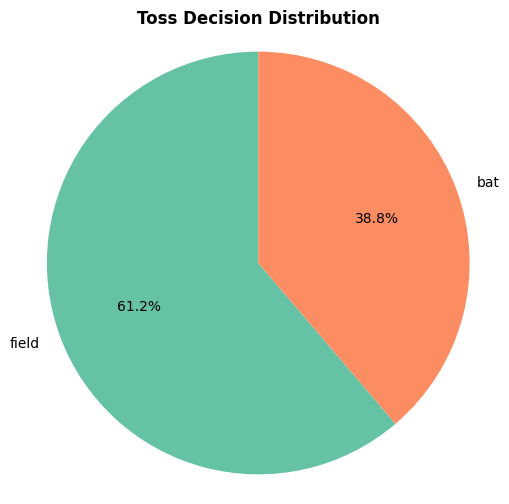

In [23]:
import matplotlib.pyplot as plt

colors = ['#66c2a5', '#fc8d62']  

ipl['toss_decision'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6,6),
    colors=colors
)

plt.title('Toss Decision Distribution', fontweight = 'bold')
plt.ylabel('')
plt.axis('equal')
plt.show()


**Toss winner vs Match winner**

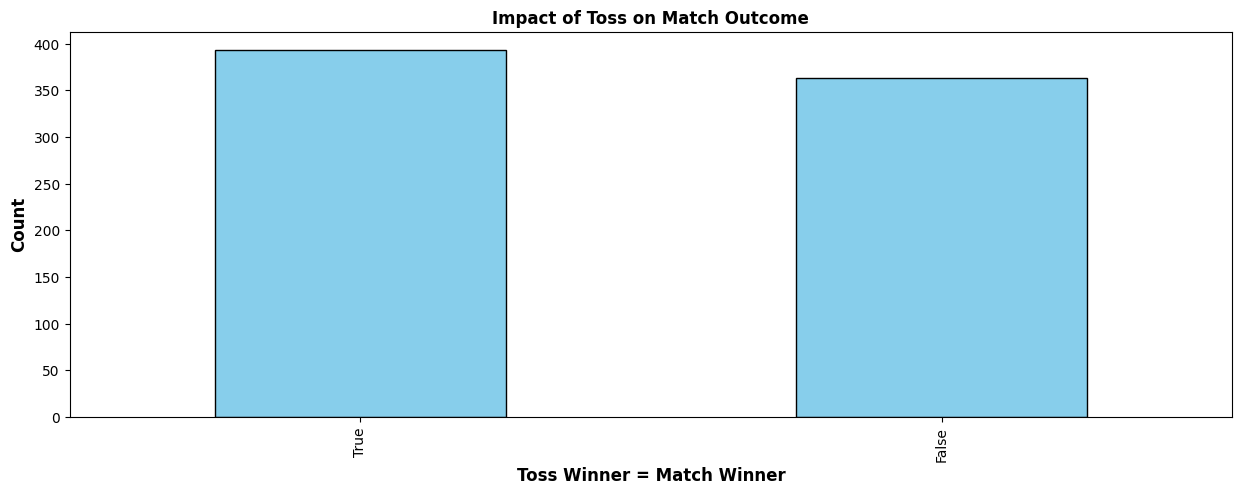

In [24]:
ipl['toss_win_match_win'] = ipl['toss_winner'] == ipl['winner']

plt.figure(figsize=(15,5))
ipl['toss_win_match_win'].value_counts().plot(kind='bar',color = 'skyblue',edgecolor = 'black')
plt.title("Impact of Toss on Match Outcome",fontsize = 12,fontweight = 'bold')
plt.xlabel("Toss Winner = Match Winner",fontsize = 12,fontweight = 'bold')
plt.ylabel("Count",fontsize = 12,fontweight = 'bold')
plt.show()

**Venue Analysis**

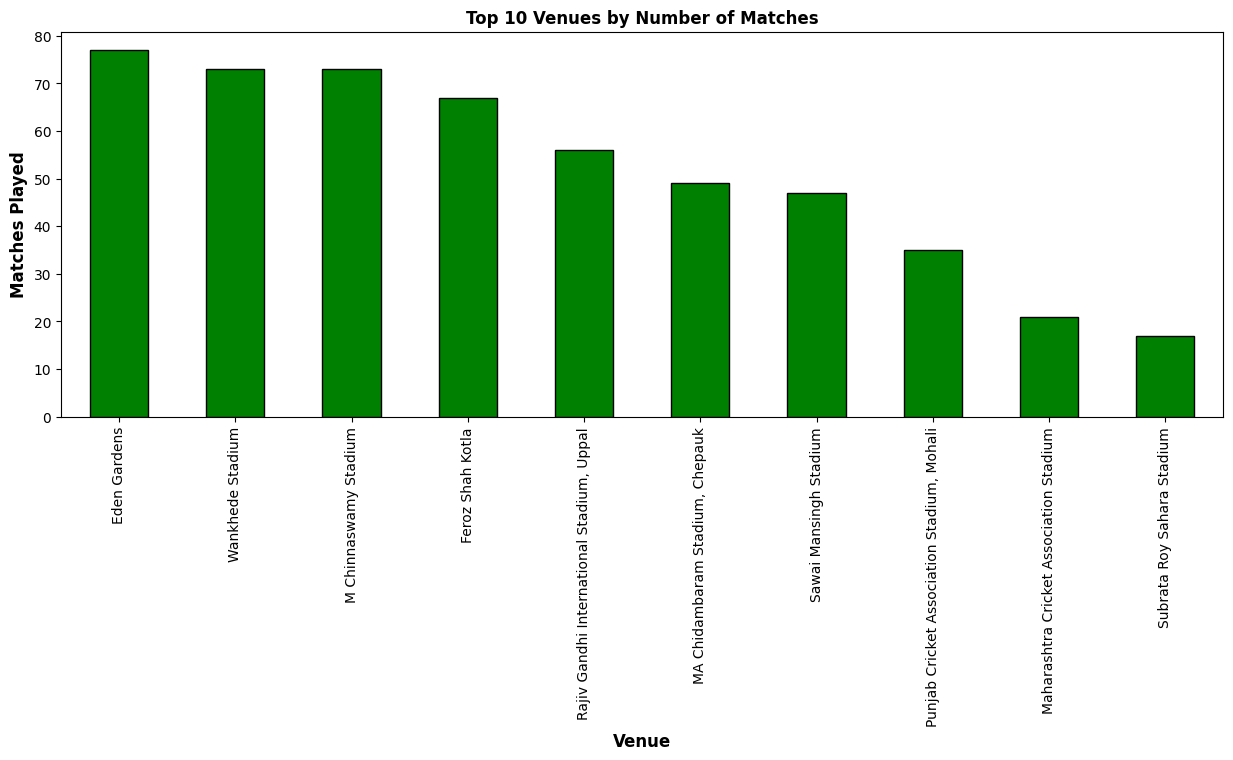

In [25]:
plt.figure(figsize=(15,5))
ipl['venue'].value_counts().head(10).plot(kind='bar',color = 'green',edgecolor = 'black')
plt.title("Top 10 Venues by Number of Matches",fontsize = 12,fontweight = 'bold')
plt.xlabel("Venue",fontsize = 12,fontweight = 'bold')
plt.ylabel("Matches Played",fontsize = 12,fontweight = 'bold')
plt.xticks(rotation=90)
plt.show()


**Player of the Match**

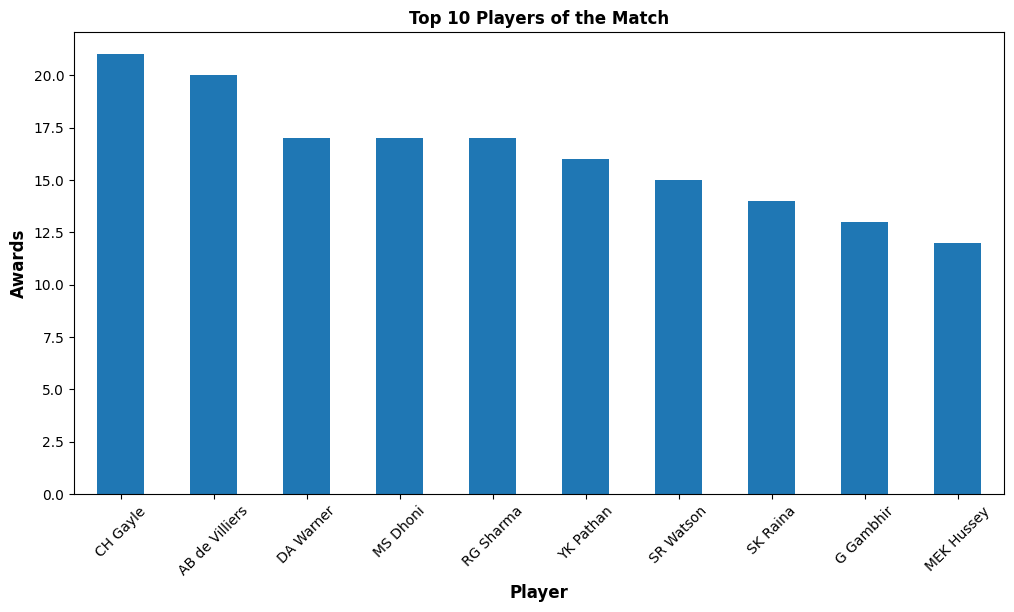

In [26]:
plt.figure(figsize=(12,6))
ipl['player_of_match'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Players of the Match",fontsize = 12,fontweight = 'bold')
plt.xlabel("Player",fontsize = 12,fontweight = 'bold')
plt.ylabel("Awards",fontsize = 12,fontweight = 'bold')
plt.xticks(rotation=45)
plt.show()


**Matches per Season**

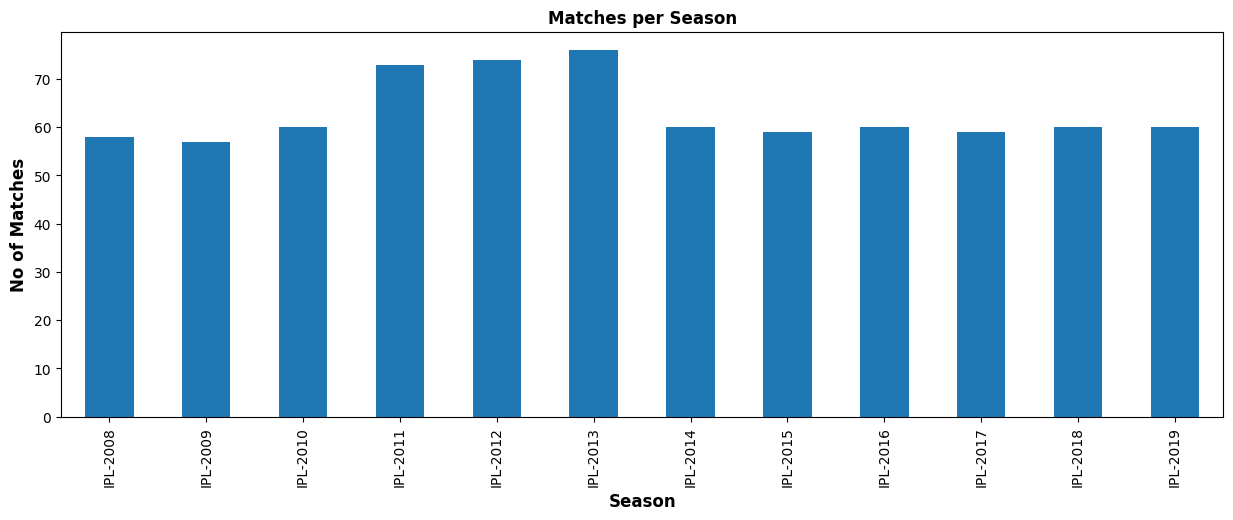

In [27]:
plt.figure(figsize=(15,5))
ipl['Season'].value_counts().sort_index().plot(kind='bar')
plt.title('Matches per Season',fontsize = 12,fontweight = 'bold')
plt.xlabel("Season",fontsize = 12,fontweight = 'bold')
plt.ylabel("No of Matches",fontsize = 12,fontweight = 'bold')
plt.show()


**Correlation Analysis**

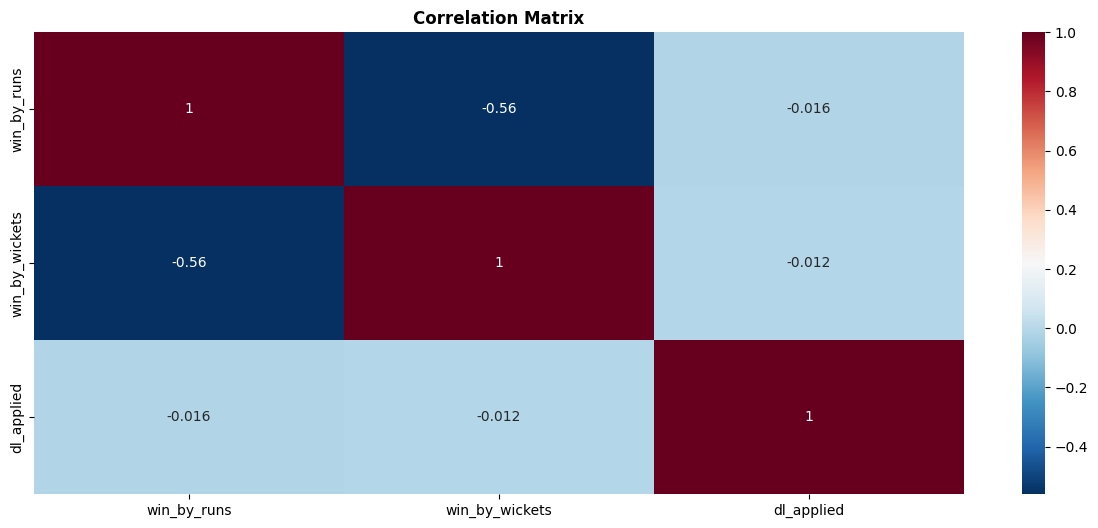

In [28]:
plt.figure(figsize=(15,6))
sns.heatmap(
    ipl[['win_by_runs','win_by_wickets','dl_applied']].corr(),
    annot=True, cmap='RdBu_r'
)
plt.title('Correlation Matrix', fontweight = 'bold')
plt.show()


#  **Outlier Detection**

**Win by Runs**

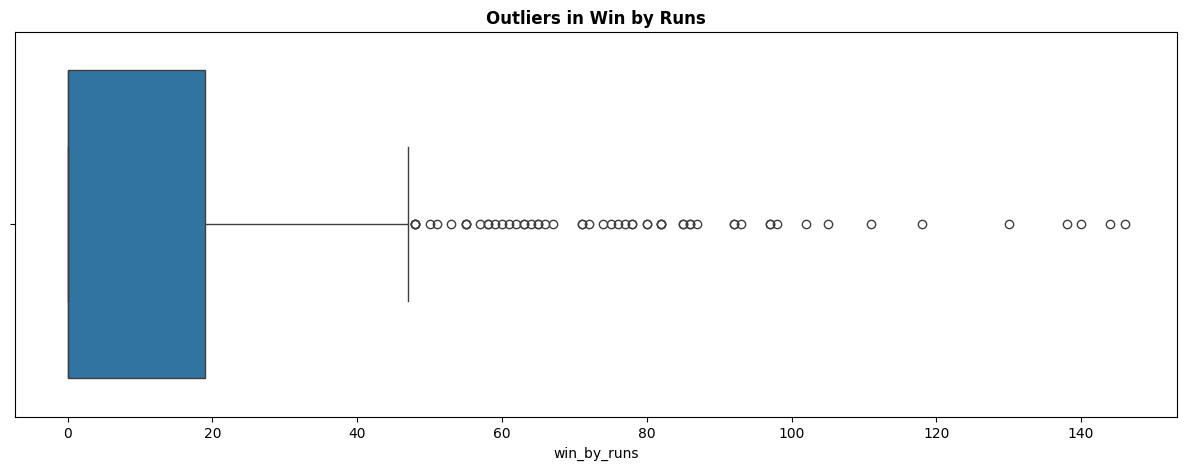

In [29]:
plt.figure(figsize=(15,5))
sns.boxplot(x=ipl['win_by_runs'])
plt.title('Outliers in Win by Runs',fontsize = 12,fontweight = 'bold')
plt.show()

**Win by Wickets**

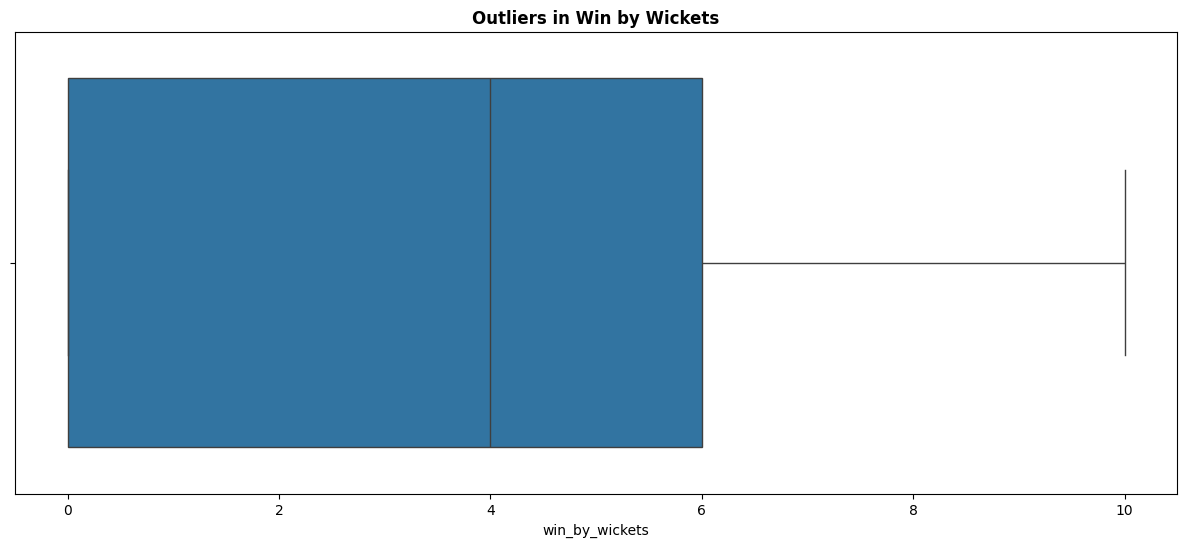

In [30]:
plt.figure(figsize=(15,6))
sns.boxplot(x=ipl['win_by_wickets'])
plt.title('Outliers in Win by Wickets',fontsize = 12,fontweight = 'bold')
plt.show()

#   **Data Preprocessing**

In [31]:
ipl.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,toss_win_match_win
0,1,IPL-2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,False
1,2,IPL-2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiants,Rising Pune Supergiants,field,normal,0,Rising Pune Supergiants,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,True
2,3,IPL-2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,True
3,4,IPL-2017,Indore,2017-04-08,Rising Pune Supergiants,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,True
4,5,IPL-2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,AK Chaudhary,C Shamshuddin,True


In [32]:
X = ipl.drop(
    ['winner', 'id', 'date', 'player_of_match'],
    axis=1
)

In [33]:
y = ipl['winner']

In [34]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
num_cols = ['win_by_runs', 'win_by_wickets', 'dl_applied']

In [37]:
le = LabelEncoder()

y_encoded = le.fit_transform(ipl['winner'])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [39]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [40]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [41]:
models = {
    
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
}

In [42]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    results.append({
        
        'Model': name,
        'Accuracy': acc,
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })
    
    print(f"\n -------{name}--------- ")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    


 -------Logistic Regression--------- 
Accuracy: 0.5263157894736842
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.40      0.50        20
           1       0.33      0.33      0.33         6
           2       0.45      0.33      0.38        15
           3       1.00      1.00      1.00         3
           4       0.43      0.38      0.40        16
           5       0.00      0.00      0.00         1
           6       0.50      0.63      0.56        19
           7       0.58      0.68      0.62        22
           8       0.48      0.73      0.58        15
           9       0.00      0.00      0.00         5
          10       0.67      0.59      0.62        17
          11       0.57      0.67      0.62        12
          12       0.00      0.00      0.00         1

    accuracy                           0.53       152
   macro avg       0.44      0.44      0.43       152
weighted avg       0.52      0.53      0.5

In [43]:
results_df = pd.DataFrame(results)
results_df.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.967105,0.962869,0.967105,0.963991
3,Random Forest,0.861842,0.855237,0.861842,0.854470
2,Decision Tree,0.848684,0.873823,0.848684,0.850350
1,KNN,0.625000,0.656798,0.625000,0.625884
0,Logistic Regression,0.526316,0.523456,0.526316,0.514590


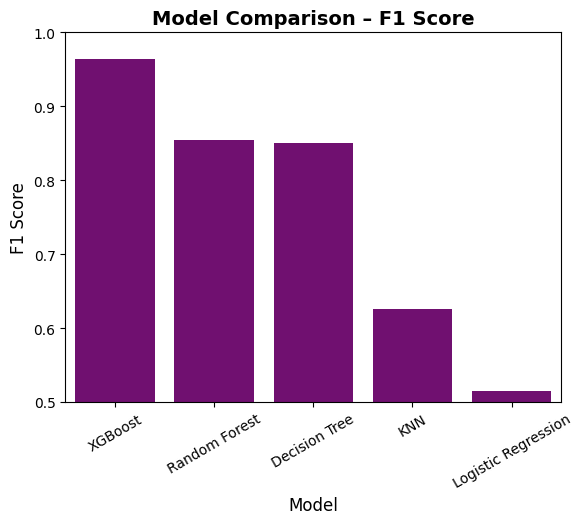

In [44]:
results_df_sorted = results_df.sort_values(by='F1 Score', ascending=False)

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df_sorted,
    color = 'purple'
)

plt.title("Model Comparison – F1 Score", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.xticks(rotation=30)
plt.ylim(0.5,1.0)

plt.show()

# **Cross Validation**

In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score


X = pd.get_dummies(X, drop_first=True)

xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42
)

scores = cross_val_score(
    xgb,
    X_encoded,
    y_encoded,
    cv=5,
    scoring='f1_macro'
)

print("Cross Validation Scores:", scores)
print("Mean F1 Score:", scores.mean())
print("Standard Deviation:", scores.std())

Cross Validation Scores: [0.87360149 0.9429976  0.95899101 0.78790466 0.96914193]
Mean F1 Score: 0.9065273382762417
Standard Deviation: 0.06805667536778295


In [47]:
print("Actual Values:")
print(y_test[:20])

print("\nPredicted Values:")
print(y_pred[:20])

Actual Values:
[ 4 10  8  8  4  8  2  0 11 10 10  8  9  6 11  2  0  0  7  9]

Predicted Values:
[ 4 10  8  8  4  8  2  0 11 10 10  8  9  6 11  2  0  0  7  9]


<br>

# **HyperParameter Tuning**

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [49]:
xgb = XGBClassifier(
    
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    random_state=42
    
)

In [50]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

In [51]:
random_search = RandomizedSearchCV(
    
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,                
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV Accuracy: 0.961914848201238


In [53]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
print("----XGBOOST-----")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

----XGBOOST-----
Accuracy : 0.9802631578947368
Precision: 0.9751096491228071
Recall   : 0.9802631578947368
F1 Score : 0.9772573917310761


# **Save the Model**

In [54]:
import pickle

# Save model
pickle.dump(best_xgb, open("ipl_model.pkl", "wb"))

# Save encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))

# Save columns
pickle.dump(X_encoded.columns, open("model_columns.pkl", "wb"))

# **Conclusion:**
  
- The tuned XGBOOST model achieved 96% accuracy with strong overall performance, making it the best model for predicting winner